## Import Libraries for Heatmap generation

1) Plot without clustering
2) Split each feature into 3 different layers:
	1) Spatial, Texture, Intensity
	2) Cell Region
	3) SER-edge or STAR feature

#### z-scores: blue=low, white=mean, red=high.

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import re
from matplotlib.patches import Patch

In [3]:
rng = np.random.default_rng(seed=42)

In [4]:
from sklearn.preprocessing import StandardScaler

# Normalise for Batch 1

In [5]:
data_path = 'data/Raw_Data_Batch1_LAB1_CTX2.csv'
counts = pd.read_csv(data_path)
counts = counts.drop(columns=[
                   	"Row",
                    "Column",
                    "Timepoint",
                    "Field",
                    "Object No",
                    "X",
                    "Y",
                    "Bounding Box",
                    "Batch",
                    "Nuclei - Object No in Nuclei_all",
                    "Cellline ID"
                   ])
# Double check here
counts = counts.drop(columns=[
    'Position X [Âµm]',
	'Position Y [Âµm]',
    'Compound',
    'Concentration',
    'Cell Count'
])
print("counts (before): ", counts.shape)
counts = counts.fillna(0)
print("counts (after): ", counts.shape)

counts (before):  (20682, 1321)
counts (after):  (20682, 1321)


### For filtering specific variants

In [6]:
counts.head()

,Cell Type,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,Control,1964.49,473.458,2001,2964,747,1092250,24.1009,2558,0.547062,...,0.062429,0.055786,0.060275,0.080337,0.692103,0.179664,0.246843,0.195137,0.000550,0.004230
1,Control,2582.91,555.290,2683,3507,1303,883355,21.4986,3261,0.674363,...,0.056252,0.055994,0.062334,0.067784,0.661050,0.187395,0.229586,0.210063,0.000543,0.004167
2,Control,3105.96,806.695,2904,6924,1006,2963080,25.9725,4097,0.466701,...,0.047268,0.060245,0.063949,0.054644,0.708571,0.196272,0.287673,0.203688,0.000483,0.003577
3,Control,1677.06,552.588,1557,3253,779,753001,32.9498,2438,0.286715,...,0.084388,0.079462,0.080827,0.100119,0.681948,0.367140,0.485384,0.179421,0.000649,0.005440
4,Control,3321.61,796.328,3175,9111,1523,4354630,23.9741,4097,0.425068,...,0.057507,0.053676,0.054210,0.068928,0.770866,0.165035,0.318869,0.227847,0.000484,0.003702


In [7]:
counts[['Lysosome Spatial - Outer region Profile 3/5', 'Lysosome Spatial - Outer region Profile 3/5 SER-Dark', 'Lysosome Spatial - Outer region Profile 3/5 SER-Ridge', 'Lysosome Spatial - Outer region Profile 3/5 SER-Spot', 'Lysosome Spatial - Outer region Profile 3/5 SER-Edge', 'Mitochondria Spatial - Outer region Profile 3/5', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Dark', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Spot', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Edge']]

,Lysosome Spatial - Outer region Profile 3/5,Lysosome Spatial - Outer region Profile 3/5 SER-Dark,Lysosome Spatial - Outer region Profile 3/5 SER-Ridge,Lysosome Spatial - Outer region Profile 3/5 SER-Spot,Lysosome Spatial - Outer region Profile 3/5 SER-Edge,Mitochondria Spatial - Outer region Profile 3/5,Mitochondria Spatial - Outer region Profile 3/5 SER-Dark,Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge,Mitochondria Spatial - Outer region Profile 3/5 SER-Spot,Mitochondria Spatial - Outer region Profile 3/5 SER-Edge
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
20677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Calculate Aggregate level values

1. Get the columns that are area, roundness and ratio and non-SER features
2. Drop those columns
3. Sort the remaining columns to get their labels

In [8]:
cell_line_agg_df = counts.groupby(['Cell Type']).mean()
print("cell_line_agg (before): ", cell_line_agg_df.shape)
cell_line_agg_df = cell_line_agg_df.dropna()
print("cell_line_agg (after): ", cell_line_agg_df.shape)

cell_line_agg (before):  (4, 1320)
cell_line_agg (after):  (4, 1320)


In [9]:
heatmap_data = cell_line_agg_df
sorted_columns = sorted(heatmap_data.columns, key=lambda x: (re.split(r'\W+', x)[0], re.split(r'\W+', x)[2], re.split(r'\W+', x)[4], re.split(r'\W+', x)[1]))
heatmap_data

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,2415.820238,1068.276350,2115.358462,9310.675777,1123.228563,2.418000e+06,47.227396,3635.190569,0.133404,97.131325,...,0.066482,0.051583,0.044348,0.074617,0.730109,0.257773,0.476910,0.270425,0.000529,0.004023
LRRK2,2021.875701,1112.009004,1704.602551,9416.777551,785.303571,1.903551e+06,52.428042,3175.903571,0.221412,82.328004,...,0.060666,0.043065,0.040697,0.065448,0.723399,0.241826,0.531648,0.285185,0.000421,0.003122
PRKN,2076.053908,1952.357934,1410.677438,17065.391393,625.548616,2.735305e+06,94.056915,4003.532532,-0.133413,120.537051,...,0.083197,0.051577,0.039248,0.092716,0.748071,0.339158,0.710430,0.309782,0.000661,0.004936
SNCA,1951.625292,1429.647893,1496.251453,12805.726463,768.235761,2.151740e+06,73.047671,3316.071678,0.014999,102.527258,...,0.068528,0.047660,0.036714,0.074893,0.738253,0.372691,0.711612,0.341564,0.000580,0.004187


In [10]:
control_agg_batch_1 = heatmap_data.loc['Control']
normalised_agg_batch_1 = heatmap_data/control_agg_batch_1
normalised_agg_batch_1['Batch'] = [1,1,1,1]
normalised_agg_batch_1 = normalised_agg_batch_1.reset_index()
normalised_agg_batch_1 = normalised_agg_batch_1.set_index(['Cell Type', 'Batch'])
normalised_agg_batch_1.head()

/tmp/ipykernel_289510/1030859053.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  normalised_agg_batch_1['Batch'] = [1,1,1,1]
/tmp/ipykernel_289510/1030859053.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  normalised_agg_batch_1 = normalised_agg_batch_1.reset_index()


,,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cell Type,Batch,,,,,,,,,,,,,,,,,,,,,
Control,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
LRRK2,1,0.836931,1.040938,0.805822,1.011396,0.699149,0.787242,1.110119,0.873655,1.659708,0.847595,...,0.912520,0.834853,0.917681,0.877110,0.990809,0.938135,1.114775,1.054580,0.795016,0.776064
PRKN,1,0.859358,1.827578,0.666874,1.832884,0.556920,1.131226,1.991575,1.101327,-1.000063,1.240970,...,1.251419,0.999877,0.885008,1.242554,1.024601,1.315723,1.489652,1.145536,1.249208,1.226909
SNCA,1,0.807852,1.338275,0.707328,1.375381,0.683953,0.889884,1.546722,0.912214,0.112435,1.055553,...,1.030780,0.923940,0.827862,1.003687,1.011155,1.445807,1.492131,1.263061,1.095733,1.040797


# Normalise for Batch 2

In [11]:
data_path = 'data/Raw_Data_Batch2_LAB1_CTX3.csv'
counts = pd.read_csv(data_path)
counts = counts.drop(columns=[
                   	"Row",
                    "Column",
                    "Timepoint",
                    "Field",
                    "Object No",
                    "X",
                    "Y",
                    "Bounding Box",
                    "Batch",
                    "Nuclei - Object No in Nuclei_all",
                    "Cellline ID"
                   ])
# Double check here
counts = counts.drop(columns=[
    'Position X [Âµm]',
	'Position Y [Âµm]',
    'Compound',
    'Concentration',
    'Cell Count'
])
print("counts (before): ", counts.shape)
counts = counts.fillna(0)
print("counts (after): ", counts.shape)

counts (before):  (21575, 1321)
counts (after):  (21575, 1321)


### For filtering specific variants

In [12]:
counts.head()

,Cell Type,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,Control,1781.82,641.231,1673,6142,567,1136800,35.9875,2434,0.525557,...,0.082946,0.046338,0.049721,0.091455,0.838023,0.167946,0.476441,0.272328,0.000352,0.002980
1,Control,1816.71,434.375,1680,3628,1100,961042,23.9099,2488,0.347124,...,0.044350,0.047498,0.056952,0.055377,0.813021,0.174622,0.423302,0.239199,0.000436,0.003212
2,Control,1845.54,571.309,1783,6177,602,2567140,30.9563,2301,0.398134,...,0.053696,0.047312,0.055097,0.068640,0.810149,0.177409,0.422880,0.238063,0.000510,0.003709
3,Control,2335.50,1658.270,1918,16396,1176,2358860,71.0027,2987,0.180917,...,0.062330,0.052993,0.061070,0.074759,0.798232,0.240361,0.535547,0.282210,0.000567,0.004246
4,Control,1663.86,435.538,1540,4004,920,1356050,26.1763,2210,0.504146,...,0.044549,0.047444,0.047570,0.054420,0.764994,0.137189,0.257587,0.230397,0.000386,0.002739


In [13]:
counts[['Lysosome Spatial - Outer region Profile 3/5', 'Lysosome Spatial - Outer region Profile 3/5 SER-Dark', 'Lysosome Spatial - Outer region Profile 3/5 SER-Ridge', 'Lysosome Spatial - Outer region Profile 3/5 SER-Spot', 'Lysosome Spatial - Outer region Profile 3/5 SER-Edge', 'Mitochondria Spatial - Outer region Profile 3/5', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Dark', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Spot', 'Mitochondria Spatial - Outer region Profile 3/5 SER-Edge']]

,Lysosome Spatial - Outer region Profile 3/5,Lysosome Spatial - Outer region Profile 3/5 SER-Dark,Lysosome Spatial - Outer region Profile 3/5 SER-Ridge,Lysosome Spatial - Outer region Profile 3/5 SER-Spot,Lysosome Spatial - Outer region Profile 3/5 SER-Edge,Mitochondria Spatial - Outer region Profile 3/5,Mitochondria Spatial - Outer region Profile 3/5 SER-Dark,Mitochondria Spatial - Outer region Profile 3/5 SER-Ridge,Mitochondria Spatial - Outer region Profile 3/5 SER-Spot,Mitochondria Spatial - Outer region Profile 3/5 SER-Edge
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
21570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21571,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21572,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21573,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Calculate Aggregate level values

1. Get the columns that are area, roundness and ratio and non-SER features
2. Drop those columns
3. Sort the remaining columns to get their labels

In [14]:
cell_line_agg_df_2 = counts.groupby(['Cell Type']).mean()
print("cell_line_agg (before): ", cell_line_agg_df_2.shape)
cell_line_agg_df_2 = cell_line_agg_df_2.dropna()
print("cell_line_agg (after): ", cell_line_agg_df_2.shape)

cell_line_agg (before):  (4, 1320)
cell_line_agg (after):  (4, 1320)


In [15]:
heatmap_data_2 = cell_line_agg_df_2
sorted_columns = sorted(heatmap_data_2.columns, key=lambda x: (re.split(r'\W+', x)[0], re.split(r'\W+', x)[2], re.split(r'\W+', x)[4], re.split(r'\W+', x)[1]))
heatmap_data_2

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,2563.574199,1102.828726,2268.060822,10220.726875,1121.870407,2.581539e+06,42.060023,3731.723534,0.342945,90.713639,...,0.057867,0.050004,0.047440,0.065626,0.733117,0.231816,0.430033,0.253067,0.000531,0.003838
LRRK2,2554.584897,892.902708,2426.062772,8252.547515,1114.216216,2.137957e+06,34.443430,3438.010462,0.498057,77.020462,...,0.056915,0.044333,0.045740,0.061303,0.681281,0.229700,0.414763,0.263046,0.000518,0.003718
PRKN,2491.713812,853.857454,2319.112503,8325.489563,1144.978466,2.345937e+06,33.777458,3363.487805,0.413107,84.731887,...,0.055001,0.046726,0.050013,0.061851,0.741730,0.219070,0.434483,0.249678,0.000488,0.003532
SNCA,2481.724707,1070.166281,2226.048768,11120.918830,1140.041825,2.587974e+06,43.278984,3458.207968,0.309329,95.781467,...,0.050503,0.044517,0.043132,0.057171,0.748851,0.194336,0.386128,0.276574,0.000466,0.003356


In [16]:
control_agg_batch_2 = heatmap_data_2.loc['Control']
normalised_agg_batch_2 = heatmap_data_2/control_agg_batch_2
normalised_agg_batch_2['Batch'] = [2,2,2,2]
normalised_agg_batch_2 = normalised_agg_batch_2.reset_index()
normalised_agg_batch_2 = normalised_agg_batch_2.set_index(['Cell Type', 'Batch'])
normalised_agg_batch_2.head()

/tmp/ipykernel_289510/3444940253.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  normalised_agg_batch_2['Batch'] = [2,2,2,2]
/tmp/ipykernel_289510/3444940253.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  normalised_agg_batch_2 = normalised_agg_batch_2.reset_index()


,,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cell Type,Batch,,,,,,,,,,,,,,,,,,,,,
Control,2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
LRRK2,2,0.996493,0.809648,1.069664,0.807433,0.993177,0.828171,0.818911,0.921293,1.452292,0.849051,...,0.983558,0.886586,0.964151,0.934115,0.929294,0.990868,0.964490,1.039429,0.975113,0.968905
PRKN,2,0.971969,0.774243,1.022509,0.814569,1.020598,0.908736,0.803077,0.901323,1.204586,0.934059,...,0.950472,0.934445,1.054226,0.942478,1.011749,0.945016,1.010349,0.986608,0.918349,0.920371
SNCA,2,0.968072,0.970383,0.981477,1.088075,1.016197,1.002492,1.028981,0.926705,0.901979,1.055866,...,0.872745,0.890271,0.909176,0.871159,1.021462,0.838317,0.897903,1.092887,0.877309,0.874553


# Normalise for Batch 3

In [17]:
cell_line_agg_df_3 = counts.groupby(['Cell Type']).mean()
print("cell_line_agg (before): ", cell_line_agg_df_3.shape)
cell_line_agg_df_3 = cell_line_agg_df_3.dropna()
print("cell_line_agg (after): ", cell_line_agg_df_3.shape)

cell_line_agg (before):  (4, 1320)
cell_line_agg (after):  (4, 1320)


In [18]:
heatmap_data_3 = cell_line_agg_df_3
sorted_columns = sorted(heatmap_data_3.columns, key=lambda x: (re.split(r'\W+', x)[0], re.split(r'\W+', x)[2], re.split(r'\W+', x)[4], re.split(r'\W+', x)[1]))
heatmap_data_3

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,2563.574199,1102.828726,2268.060822,10220.726875,1121.870407,2.581539e+06,42.060023,3731.723534,0.342945,90.713639,...,0.057867,0.050004,0.047440,0.065626,0.733117,0.231816,0.430033,0.253067,0.000531,0.003838
LRRK2,2554.584897,892.902708,2426.062772,8252.547515,1114.216216,2.137957e+06,34.443430,3438.010462,0.498057,77.020462,...,0.056915,0.044333,0.045740,0.061303,0.681281,0.229700,0.414763,0.263046,0.000518,0.003718
PRKN,2491.713812,853.857454,2319.112503,8325.489563,1144.978466,2.345937e+06,33.777458,3363.487805,0.413107,84.731887,...,0.055001,0.046726,0.050013,0.061851,0.741730,0.219070,0.434483,0.249678,0.000488,0.003532
SNCA,2481.724707,1070.166281,2226.048768,11120.918830,1140.041825,2.587974e+06,43.278984,3458.207968,0.309329,95.781467,...,0.050503,0.044517,0.043132,0.057171,0.748851,0.194336,0.386128,0.276574,0.000466,0.003356


In [19]:
control_agg_batch_3 = heatmap_data_3.loc['Control']
normalised_agg_batch_3 = heatmap_data_3/control_agg_batch_3
normalised_agg_batch_3['Batch'] = [3,3,3,3]
normalised_agg_batch_3 = normalised_agg_batch_3.reset_index()
normalised_agg_batch_3 = normalised_agg_batch_3.set_index(['Cell Type', 'Batch'])
normalised_agg_batch_3.head()

/tmp/ipykernel_289510/219529593.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  normalised_agg_batch_3['Batch'] = [3,3,3,3]
/tmp/ipykernel_289510/219529593.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  normalised_agg_batch_3 = normalised_agg_batch_3.reset_index()


,,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cell Type,Batch,,,,,,,,,,,,,,,,,,,,,
Control,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
LRRK2,3,0.996493,0.809648,1.069664,0.807433,0.993177,0.828171,0.818911,0.921293,1.452292,0.849051,...,0.983558,0.886586,0.964151,0.934115,0.929294,0.990868,0.964490,1.039429,0.975113,0.968905
PRKN,3,0.971969,0.774243,1.022509,0.814569,1.020598,0.908736,0.803077,0.901323,1.204586,0.934059,...,0.950472,0.934445,1.054226,0.942478,1.011749,0.945016,1.010349,0.986608,0.918349,0.920371
SNCA,3,0.968072,0.970383,0.981477,1.088075,1.016197,1.002492,1.028981,0.926705,0.901979,1.055866,...,0.872745,0.890271,0.909176,0.871159,1.021462,0.838317,0.897903,1.092887,0.877309,0.874553


# Combining the Batches

In [20]:
combined_df = pd.concat([normalised_agg_batch_1, normalised_agg_batch_2, normalised_agg_batch_3])
combined_df

,,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cell Type,Batch,,,,,,,,,,,,,,,,,,,,,
Control,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
LRRK2,1,0.836931,1.040938,0.805822,1.011396,0.699149,0.787242,1.110119,0.873655,1.659708,0.847595,...,0.912520,0.834853,0.917681,0.877110,0.990809,0.938135,1.114775,1.054580,0.795016,0.776064
PRKN,1,0.859358,1.827578,0.666874,1.832884,0.556920,1.131226,1.991575,1.101327,-1.000063,1.240970,...,1.251419,0.999877,0.885008,1.242554,1.024601,1.315723,1.489652,1.145536,1.249208,1.226909
SNCA,1,0.807852,1.338275,0.707328,1.375381,0.683953,0.889884,1.546722,0.912214,0.112435,1.055553,...,1.030780,0.923940,0.827862,1.003687,1.011155,1.445807,1.492131,1.263061,1.095733,1.040797
Control,2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
LRRK2,2,0.996493,0.809648,1.069664,0.807433,0.993177,0.828171,0.818911,0.921293,1.452292,0.849051,...,0.983558,0.886586,0.964151,0.934115,0.929294,0.990868,0.964490,1.039429,0.975113,0.968905
PRKN,2,0.971969,0.774243,1.022509,0.814569,1.020598,0.908736,0.803077,0.901323,1.204586,0.934059,...,0.950472,0.934445,1.054226,0.942478,1.011749,0.945016,1.010349,0.986608,0.918349,0.920371
SNCA,2,0.968072,0.970383,0.981477,1.088075,1.016197,1.002492,1.028981,0.926705,0.901979,1.055866,...,0.872745,0.890271,0.909176,0.871159,1.021462,0.838317,0.897903,1.092887,0.877309,0.874553
Control,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Create additional labels for region, star types and feature types 

In [21]:
all_columns = combined_df.columns
regions = []
feature_types = []
star_types = []
organelles = []
ser_types = []

for col in all_columns:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]
    region = f"{col_sections[2]} {col_sections[3]}"
    feature = col_sections[1]
    star_type = col_sections[4]
    regions.append(region)

    if ('Symmetry' in col_sections) or ('Threshold' in col_sections) or ('Axial' in col_sections) or ('Radial' in col_sections):
        star_types.append(star_type)
        ser_types.append('None')
    elif  ('SER' in col_sections):
        star_types.append('SER')
        if 'Dark' in col_sections:
            ser_types.append('Dark')
        elif 'Ridge' in col_sections:
            ser_types.append('Ridge')
        elif 'Spot' in col_sections:
            ser_types.append('Spot')
        elif 'Edge' in col_sections:
            ser_types.append('Edge')
        elif 'Bright' in col_sections:
            ser_types.append('Bright')
        elif 'Saddle' in col_sections:
            ser_types.append('Saddle')
        elif 'Valley' in col_sections:
            ser_types.append('Valley')
        elif 'Hole' in col_sections:
            ser_types.append('Hole')
        else:
            ser_types.append('None')
        print(col_sections)
    else:
        star_types.append('None')
        ser_types.append('None')
        # print(star_type)
   
    feature_types.append(feature)
    organelles.append(organelle)


['Lysosome', 'Spatial', 'Nucleus', 'region', 'Profile', '1', '2', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Nucleus', 'region', 'Profile', '2', '2', 'SER', 'Dark']
['Lysosome', 'Spatial', 'Nucleus', 'region', 'Profile', '1', '2', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Nucleus', 'region', 'Profile', '2', '2', 'SER', 'Ridge']
['Lysosome', 'Spatial', 'Nucleus', 'region', 'Profile', '1', '2', 'SER', 'Spot']
['Lysosome', 'Spatial', 'Nucleus', 'region', 'Profile', '2', '2', 'SER', 'Spot']
['Lysosome', 'Spatial', 'Nucleus', 'region', 'Profile', '1', '2', 'SER', 'Edge']
['Lysosome', 'Spatial', 'Nucleus', 'region', 'Profile', '2', '2', 'SER', 'Edge']
['Lysosome', 'Texture', 'Nucleus', 'region', 'SER', 'Spot', '1', 'px']
['Lysosome', 'Texture', 'Nucleus', 'region', 'SER', 'Hole', '1', 'px']
['Lysosome', 'Texture', 'Nucleus', 'region', 'SER', 'Edge', '1', 'px']
['Lysosome', 'Texture', 'Nucleus', 'region', 'SER', 'Ridge', '1', 'px']
['Lysosome', 'Texture', 'Nucleus', 'region', 'SER', 'Valley', '1'

## Begin adding additional labels

In [22]:
set(organelles)

{'General', 'Lysosome', 'Mitochondria'}

In [23]:
set(regions)

{'Cell region',
 'Inner region',
 'Middle region',
 'Nucleus region',
 'Outer region'}

In [24]:
set(star_types)

{'Axial', 'None', 'Radial', 'SER', 'Symmetry', 'Threshold'}

In [25]:
set(feature_types)

{'Dimension', 'Intensity', 'Spatial', 'Texture'}

In [26]:
set(ser_types)

{'Bright', 'Dark', 'Edge', 'Hole', 'None', 'Ridge', 'Saddle', 'Spot', 'Valley'}

In [27]:
len(ser_types)

1320

In [28]:
len(feature_types)

1320

In [29]:
len(star_types)

1320

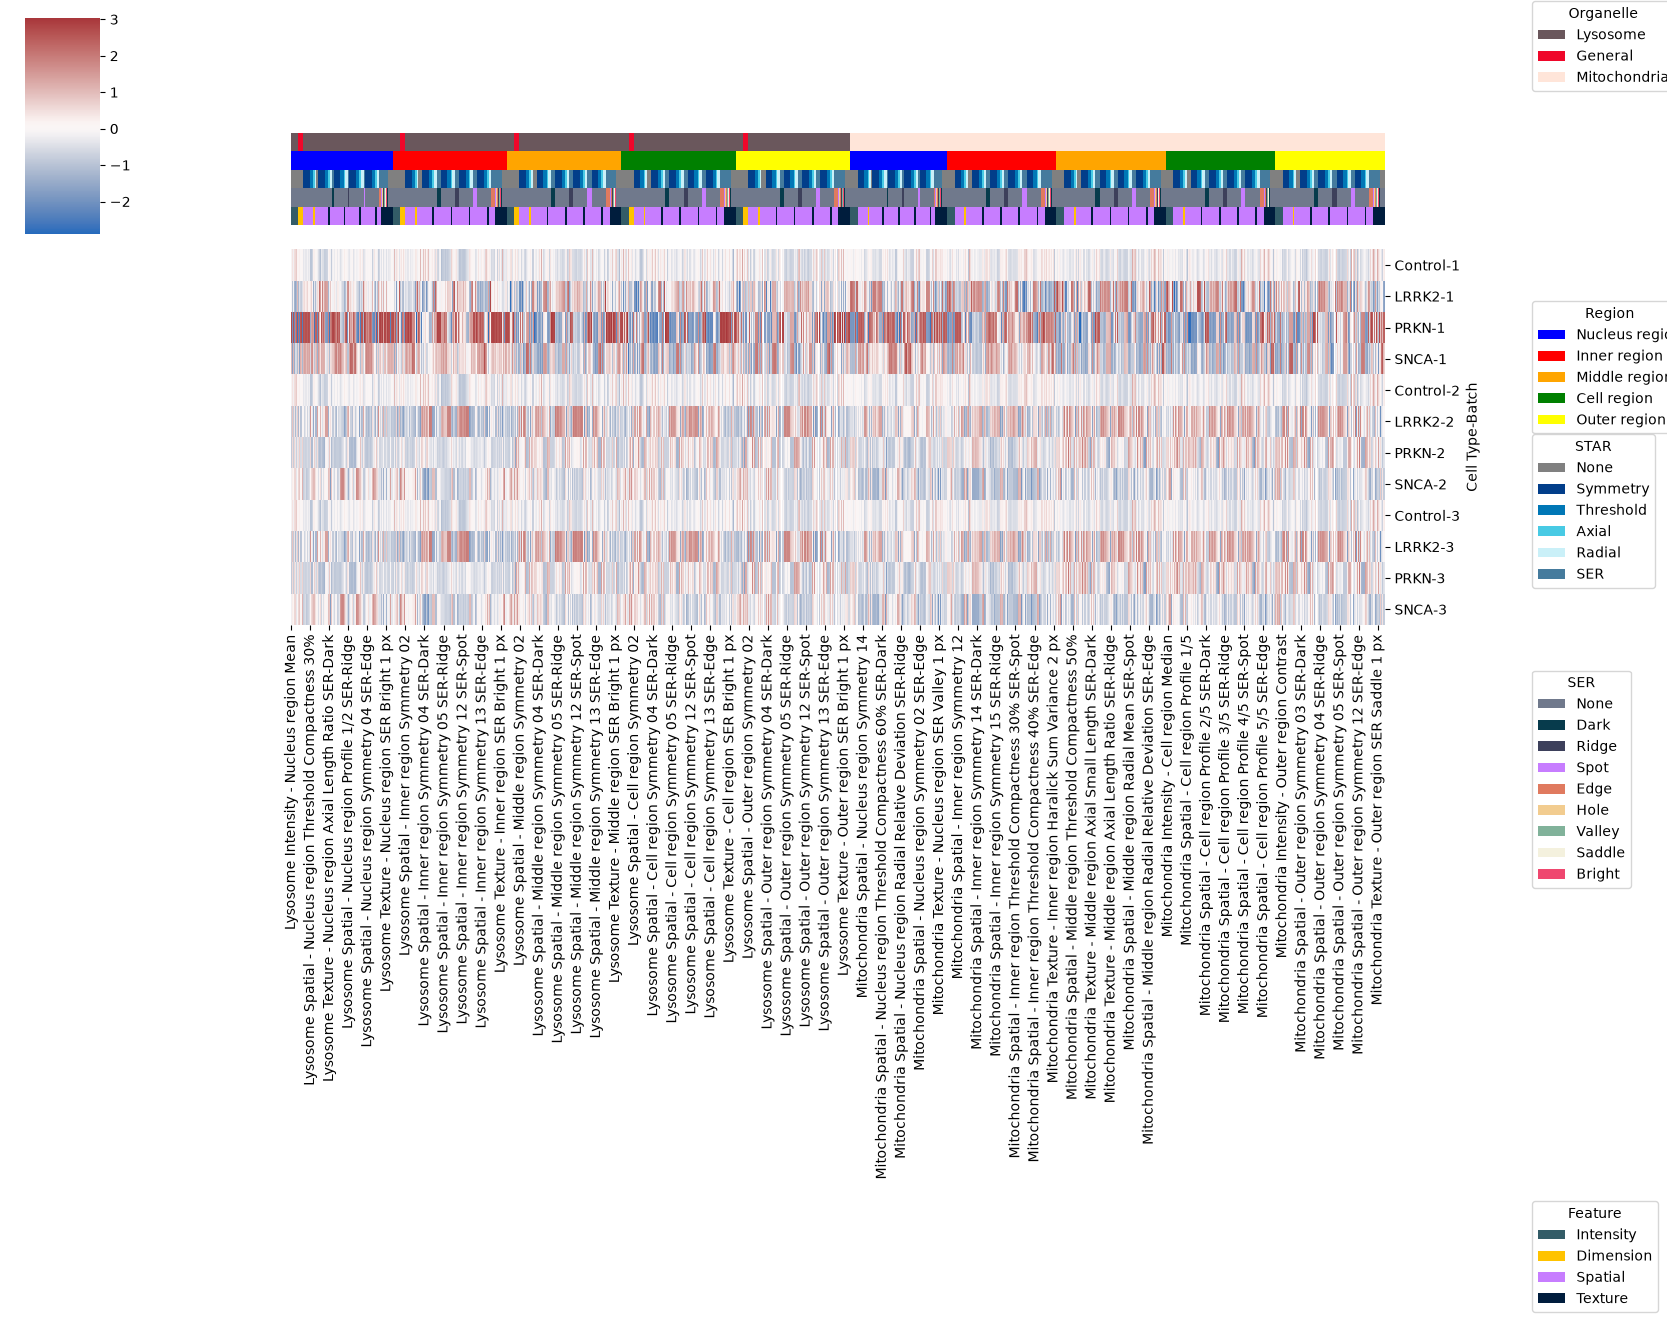

In [37]:
# Initialise an organelles array
organelle_colors = [

]

lut_organelle = {

}

for organelle in organelles:
    color = 'Grey'
    if organelle == 'General':
        color = "#ef072a"
    elif organelle == 'Mitochondria':
        color = '#ffe5d9'
    else:
        color = "#6A575C"

    lut_organelle[organelle] = color
    organelle_colors.append(color)

# Initialise a colours array
region_colors = [

]

lut = {

}


# Initialise a colours array for STAR
star_colors = [

]

lut_star = {

}
for star in star_types:
    if star == 'None':
        star_color = 'Grey'
    elif star == 'Symmetry':
        star_color = '#023e8a'
    elif star == 'Threshold':
        star_color = '#0077b6'
    elif star == 'Axial':
        star_color = '#48cae4'
    elif star == 'Radial':
        star_color = '#caf0f8'
    else:
        star_color = '#457b9d'

    lut_star[star] = star_color
    star_colors.append(star_color)
    


# Go over each region
for region in regions:
    if region == 'Nucleus region':
        region_color = 'Blue'
        lut['Nucleus region'] = 'Blue'
    elif region == 'Inner region':
        region_color = 'Red'
        lut['Inner region'] = 'Red'
    elif region == 'Middle region':
        region_color = 'Orange'
        lut['Middle region'] = 'Orange'
    elif region == 'Outer region':
        region_color = 'Yellow'
        lut['Outer region'] = 'Yellow'
    elif region == 'Cell region':
        region_color = 'Green'
        lut['Cell region'] = 'Green'

    lut[region] = region_color
    region_colors.append(region_color)

# Feature colours
feature_colours = []
lut_feature = {

}
for feature in feature_types:
    if feature == 'Intensity':
        feature_color = '#335c67'
    elif feature == 'Dimension':
        feature_color = '#ffc300'
    elif feature == 'Spatial':
        feature_color = '#c77dff'
    else:
        feature_color = '#001d3d'

    lut_feature[feature] = feature_color

    feature_colours.append(feature_color)


# SER colours
ser_colours = [

]

lut_ser = {

}

for ser in ser_types:
    if ser == 'Saddle':
        ser_color = '#f4f1de'
    elif ser == 'Edge':
        ser_color = '#e07a5f'
    elif ser == 'Ridge':
        ser_color = '#3d405b'
    elif ser == 'Valley':
            ser_color = '#81b29a'
    elif ser == 'Hole':
            ser_color = '#f2cc8f'
    elif ser == 'Spot':
        ser_color = '#c77dff'
    elif ser == 'Dark':
        ser_color = '#073b4c'
    elif ser == 'Bright':
        ser_color = '#ef476f'
    else:
        ser_color = '#70798c'

    lut_ser[ser] = ser_color

    ser_colours.append(ser_color)    



# Figure this legend part out later
handles = [Patch(facecolor=lut[name]) for name in lut]
handles_2 = [Patch(facecolor=lut_star[name]) for name in lut_star]
handles_3 = [Patch(facecolor=lut_feature[name]) for name in lut_feature]
handles_4 = [Patch(facecolor=lut_organelle[name]) for name in lut_organelle]
handles_5 = [Patch(facecolor=lut_ser[name]) for name in lut_ser]

g = sns.clustermap(
    combined_df,
    cmap='vlag',
    figsize=(15, 12),
    row_cluster=False,
    col_cluster=False,
    z_score=1,
    col_colors=[organelle_colors, region_colors, star_colors, ser_colours, feature_colours]
)

pos = g.ax_heatmap.get_position()

# 3. Define how much gap we want to add
gap = 0.02 

g.ax_heatmap.set_position([pos.x0, pos.y0, pos.width, pos.height - gap])

ax= plt.gca()
# 1. First Legend (Organelle) - Top Left of anchor
leg1 = plt.legend(handles_4, lut_organelle, title='Organelle',
                  bbox_to_anchor=(1.02, 1.0), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg1) # Pin it so it doesn't get overwritten

# 2. Second Legend (Region) - Shifted down vertically (e.g., to y=0.75)
leg2 = plt.legend(handles, lut, title='Region',
                  bbox_to_anchor=(1.02, 0.75), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg2)

# 3. Third Legend (Feature) - Shifted further down (e.g., to y=0.50)
leg3 = plt.legend(handles_2, lut_star, title='STAR',
                  bbox_to_anchor=(1.02, 0.50), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg3)

# SER
leg5 = plt.legend(handles_5, lut_ser, title='SER',
                  bbox_to_anchor=(1.02, 0.25), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg5)

# 4. Fourth Legend (STAR) - Placed at the bottom right corner
leg4 = plt.legend(handles_3, lut_feature, title='Feature',
                  bbox_to_anchor=(1.02, 0.0), bbox_transform=plt.gcf().transFigure, loc='upper left')






In [43]:
combined_df[combined_df.columns[combined_df.std() == 0]]

,
Cell Type,Batch
Control,1
LRRK2,1
PRKN,1
SNCA,1
Control,2
LRRK2,2
PRKN,2
SNCA,2
Control,3


In [44]:
combined_df = combined_df.astype('float')
print(np.isinf(combined_df).sum().sum())
print(combined_df.isna().sum().sum())
# print(combined_df)
zero_variance_cols = combined_df.columns[combined_df.std() == 0].tolist()
new_combined_df = combined_df
new_combined_df = new_combined_df.drop(columns=zero_variance_cols)

0
120


In [45]:
heatmap_data[zero_variance_cols]

""
Cell Type
Control
LRRK2
PRKN
SNCA


In [46]:
print(zero_variance_cols)

[]


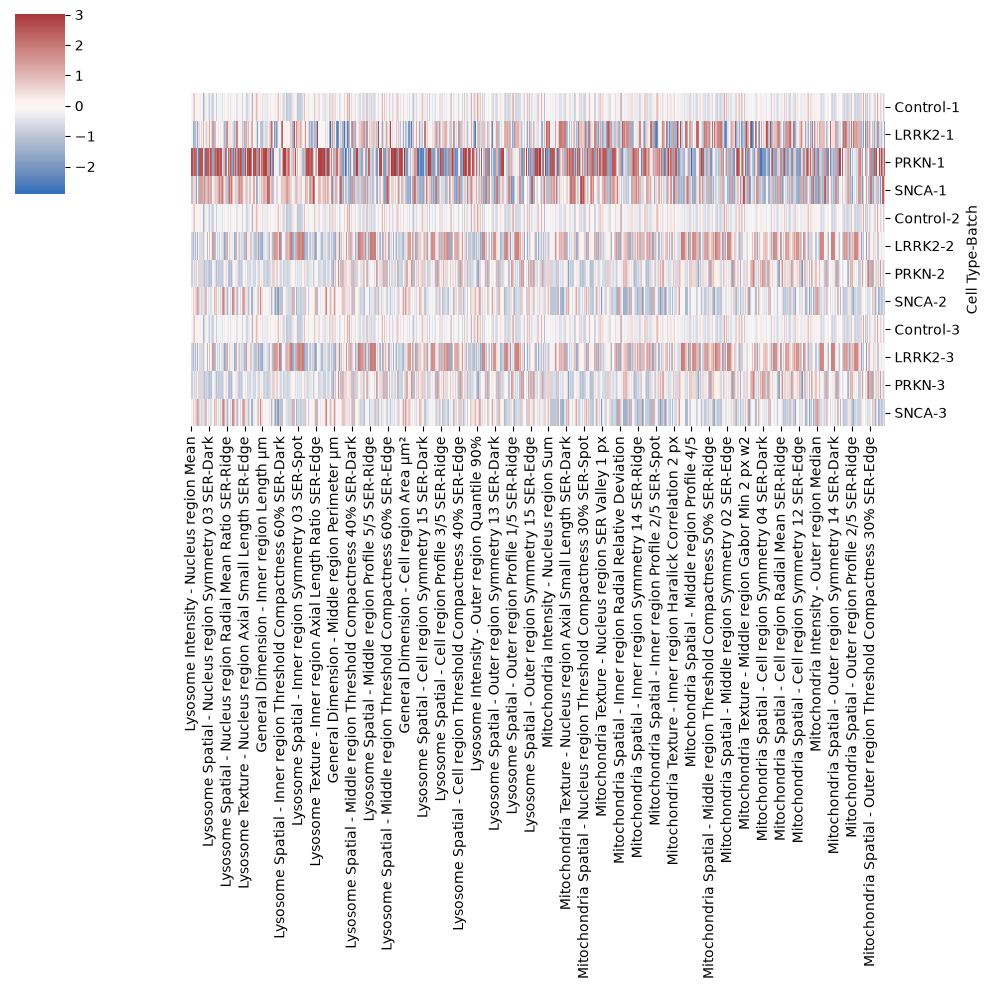

In [47]:
g = sns.clustermap(
    combined_df,
    cmap='vlag',
    figsize=(10, 10),
    row_cluster=False,
    col_cluster=False,
    z_score=1,
    center=0,

)

/home/rushik-sriramoju/cell_morphomics_dashboard_pipeline/.venv-1/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


ValueError: The condensed distance matrix must contain only finite values.

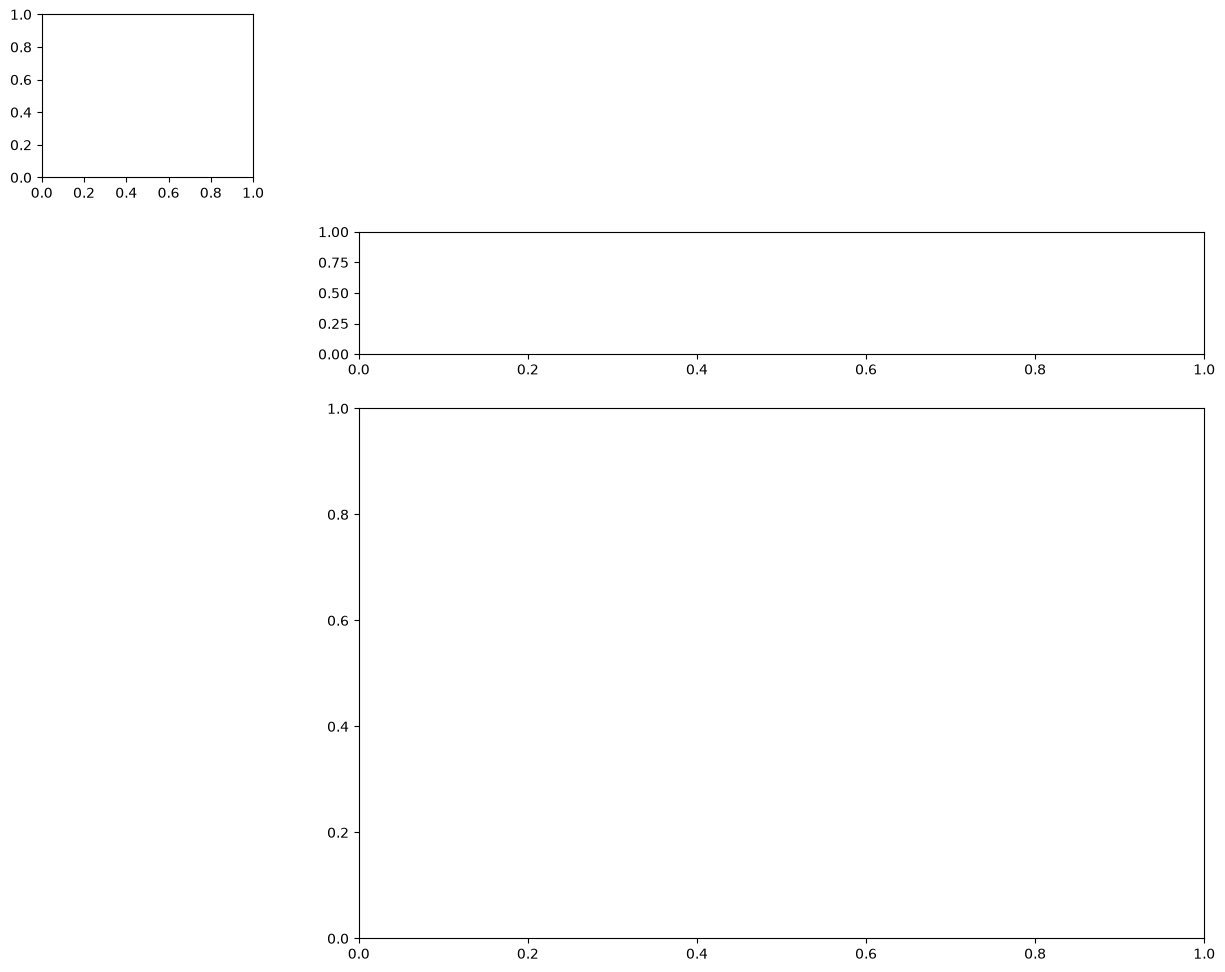

In [ ]:
g = sns.clustermap(
    new_combined_df,
    cmap='vlag',
    figsize=(15, 12),
    row_cluster=False,
    col_cluster=True,
    z_score=1,
    col_colors=[organelle_colors, region_colors, star_colors, ser_colours, feature_colours]
)

pos = g.ax_heatmap.get_position()

# 3. Define how much gap we want to add
gap = 0.02 

g.ax_heatmap.set_position([pos.x0, pos.y0, pos.width, pos.height - gap])

ax= plt.gca()
# 1. First Legend (Organelle) - Top Left of anchor
leg1 = plt.legend(handles_4, lut_organelle, title='Organelle',
                  bbox_to_anchor=(1.02, 1.0), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg1) # Pin it so it doesn't get overwritten

# 2. Second Legend (Region) - Shifted down vertically (e.g., to y=0.75)
leg2 = plt.legend(handles, lut, title='Region',
                  bbox_to_anchor=(1.02, 0.75), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg2)

# 3. Third Legend (Feature) - Shifted further down (e.g., to y=0.50)
leg3 = plt.legend(handles_2, lut_star, title='STAR',
                  bbox_to_anchor=(1.02, 0.50), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg3)

# The SER feature
leg5 = plt.legend(handles_5, lut_ser, title='SER',
                  bbox_to_anchor=(1.02, 0.25), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg5)

# 4. Fourth Legend (STAR) - Placed at the bottom right corner
leg4 = plt.legend(handles_3, lut_feature, title='Feature',
                  bbox_to_anchor=(1.02, 0.0), bbox_transform=plt.gcf().transFigure, loc='upper left')


